In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils.knn import KNN
from utils.metrics_evaluator import MetricsEvaluator
from utils.k_fold_cross_validation import KFoldCrossValidation
from utils.helpers import min_max_normalization, to_percent

In [41]:
def drawHistogram(df: pd.DataFrame, col: str):
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f'Distribusi Data {col}')
    plt.show()

In [64]:
def drawBoxPlot(df: pd.DataFrame):
    plt.figure(figsize=(8, 6))
    numeric_df = df.select_dtypes(include=[np.number])
    numeric_df.boxplot()
    plt.title("Box Plot Setiap Fitur")
    plt.ylabel("Nilai")
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.show()


    # plt.figure(figsize=(6, 4))
    # sns.boxplot(x=df[col].dropna())
    # plt.title(f'Boxplot Data {col}')
    # plt.show()

In [65]:
# dm2 anu murni dm2 hngkl
# dm2-all anu boga panyakit lain diasupken, tuluy direname
df = pd.read_csv("dataset-dm2.csv")
df

,umur,jenis_kelamin,sistolik,diastolik,gds,diagnosa
0,43.0,L,90.0,70.0,154.0,DM2
1,77.0,P,160.0,90.0,71.0,DM2
2,38.0,P,90.0,70.0,154.0,DM2
3,41.0,P,NaN,NaN,NaN,DM2
4,42.0,P,NaN,NaN,227.0,DM2
...,...,...,...,...,...,...
801,35.0,Perempuan,127.0,84.0,118.0,NDM
802,23.0,Perempuan,121.0,79.0,109.0,NDM
803,29.0,Perempuan,118.0,74.0,96.0,NDM
804,22.0,Perempuan,119.0,78.0,95.0,NDM


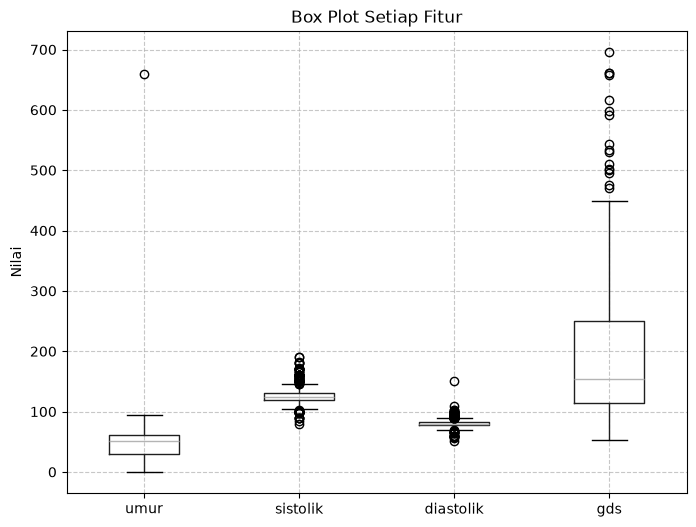

In [66]:
drawBoxPlot(df)

In [43]:
missingSistolikCount = df['sistolik'].isna().sum()
print(missingSistolikCount)

24


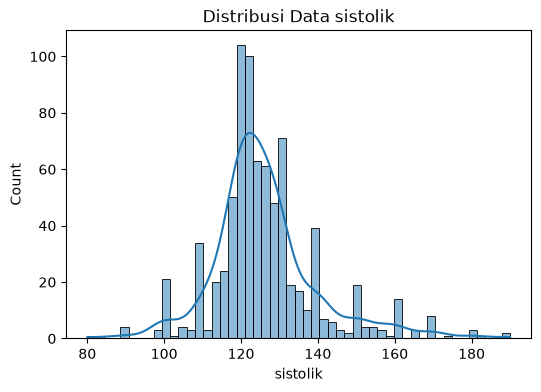

In [44]:
drawHistogram(df, 'sistolik')

In [45]:
# Filling missing 'sistolik' values with the mean
df['sistolik'] = df['sistolik'].fillna(df['sistolik'].mean())
df

,umur,jenis_kelamin,sistolik,diastolik,gds,diagnosa
0,43.0,L,90.000000,70.0,154.0,DM2
1,77.0,P,160.000000,90.0,71.0,DM2
2,38.0,P,90.000000,70.0,154.0,DM2
3,41.0,P,126.200767,NaN,NaN,DM2
4,42.0,P,126.200767,NaN,227.0,DM2
...,...,...,...,...,...,...
801,35.0,Perempuan,127.000000,84.0,118.0,NDM
802,23.0,Perempuan,121.000000,79.0,109.0,NDM
803,29.0,Perempuan,118.000000,74.0,96.0,NDM
804,22.0,Perempuan,119.000000,78.0,95.0,NDM


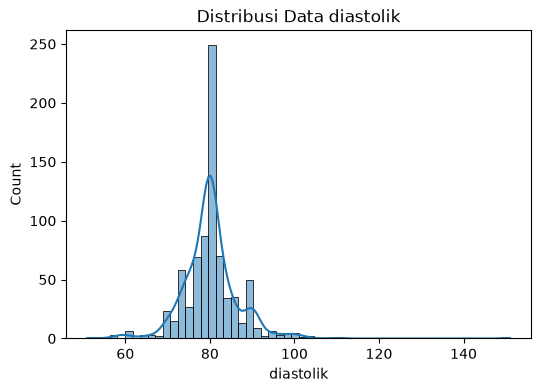

In [46]:
drawHistogram(df, 'diastolik')

In [47]:
missingDiastolikCount = df['diastolik'].isna().sum()
print(missingDiastolikCount)

24


In [48]:
# Mengisi nilai yang hilang pada kolom Diastolik dengan nilai rata-rata mean (nilai rata-rata)
df['diastolik'] = df['diastolik'].fillna(df['diastolik'].mean())
df

,umur,jenis_kelamin,sistolik,diastolik,gds,diagnosa
0,43.0,L,90.000000,70.000000,154.0,DM2
1,77.0,P,160.000000,90.000000,71.0,DM2
2,38.0,P,90.000000,70.000000,154.0,DM2
3,41.0,P,126.200767,80.202046,NaN,DM2
4,42.0,P,126.200767,80.202046,227.0,DM2
...,...,...,...,...,...,...
801,35.0,Perempuan,127.000000,84.000000,118.0,NDM
802,23.0,Perempuan,121.000000,79.000000,109.0,NDM
803,29.0,Perempuan,118.000000,74.000000,96.0,NDM
804,22.0,Perempuan,119.000000,78.000000,95.0,NDM


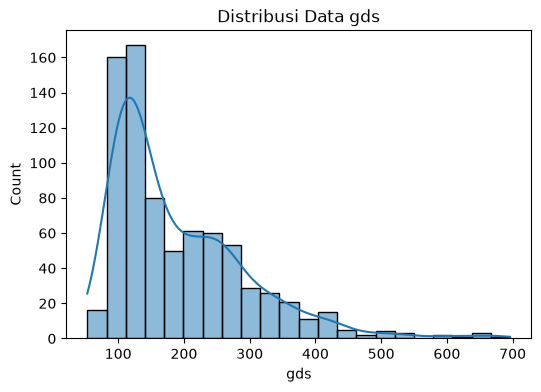

In [49]:
drawHistogram(df, 'gds')

In [50]:
missingGdsCount = df['gds'].isna().sum()
print(missingGdsCount)

36


In [51]:
# Mengisi nilai yang hilang pada kolom gds dengan nilai median (nilai tengah)
df['gds'] = df['gds'].fillna(df['gds'].median())
df

,umur,jenis_kelamin,sistolik,diastolik,gds,diagnosa
0,43.0,L,90.000000,70.000000,154.0,DM2
1,77.0,P,160.000000,90.000000,71.0,DM2
2,38.0,P,90.000000,70.000000,154.0,DM2
3,41.0,P,126.200767,80.202046,154.0,DM2
4,42.0,P,126.200767,80.202046,227.0,DM2
...,...,...,...,...,...,...
801,35.0,Perempuan,127.000000,84.000000,118.0,NDM
802,23.0,Perempuan,121.000000,79.000000,109.0,NDM
803,29.0,Perempuan,118.000000,74.000000,96.0,NDM
804,22.0,Perempuan,119.000000,78.000000,95.0,NDM


In [52]:
missingGenderCount = df['jenis_kelamin'].isna().sum()
print(missingGenderCount)

0


In [53]:
# Mengisi nilai yang hilang pada kolom jenis_kelamin dengan nilai modus (nilai yang sering mucul)
df['jenis_kelamin'] = df['jenis_kelamin'].fillna(df['jenis_kelamin'].mode()[0])
df

,umur,jenis_kelamin,sistolik,diastolik,gds,diagnosa
0,43.0,L,90.000000,70.000000,154.0,DM2
1,77.0,P,160.000000,90.000000,71.0,DM2
2,38.0,P,90.000000,70.000000,154.0,DM2
3,41.0,P,126.200767,80.202046,154.0,DM2
4,42.0,P,126.200767,80.202046,227.0,DM2
...,...,...,...,...,...,...
801,35.0,Perempuan,127.000000,84.000000,118.0,NDM
802,23.0,Perempuan,121.000000,79.000000,109.0,NDM
803,29.0,Perempuan,118.000000,74.000000,96.0,NDM
804,22.0,Perempuan,119.000000,78.000000,95.0,NDM


In [11]:
# Mapping Gender: P (Perempuan) to 1, L (Laki-laki) to 0
df['transformed_gender'] = df['jenis_kelamin'].map(lambda e: 1 if e == 'P' or e == 'Perempuan' else 0)
df

,umur,jenis_kelamin,sistolik,diastolik,gds,diagnosa,transformed_gender
0,43.0,L,90.000000,70.000000,154.0,DM2,0
1,77.0,P,160.000000,90.000000,71.0,DM2,1
2,38.0,P,90.000000,70.000000,154.0,DM2,1
3,41.0,P,126.200767,80.202046,154.0,DM2,1
4,42.0,P,126.200767,80.202046,227.0,DM2,1
...,...,...,...,...,...,...,...
801,35.0,Perempuan,127.000000,84.000000,118.0,NDM,1
802,23.0,Perempuan,121.000000,79.000000,109.0,NDM,1
803,29.0,Perempuan,118.000000,74.000000,96.0,NDM,1
804,22.0,Perempuan,119.000000,78.000000,95.0,NDM,1


In [12]:
df['diagnosa'] = df['diagnosa'].map(lambda e: 1 if e == 'DM2' else 0)
df

,umur,jenis_kelamin,sistolik,diastolik,gds,diagnosa,transformed_gender
0,43.0,L,90.000000,70.000000,154.0,1,0
1,77.0,P,160.000000,90.000000,71.0,1,1
2,38.0,P,90.000000,70.000000,154.0,1,1
3,41.0,P,126.200767,80.202046,154.0,1,1
4,42.0,P,126.200767,80.202046,227.0,1,1
...,...,...,...,...,...,...,...
801,35.0,Perempuan,127.000000,84.000000,118.0,0,1
802,23.0,Perempuan,121.000000,79.000000,109.0,0,1
803,29.0,Perempuan,118.000000,74.000000,96.0,0,1
804,22.0,Perempuan,119.000000,78.000000,95.0,0,1


In [13]:
# Normalisasi kolom sistolik
df['norm_sistolik'] = min_max_normalization(df['sistolik'])
df

,umur,jenis_kelamin,sistolik,diastolik,gds,diagnosa,transformed_gender,norm_sistolik
0,43.0,L,90.000000,70.000000,154.0,1,0,0.090909
1,77.0,P,160.000000,90.000000,71.0,1,1,0.727273
2,38.0,P,90.000000,70.000000,154.0,1,1,0.090909
3,41.0,P,126.200767,80.202046,154.0,1,1,0.420007
4,42.0,P,126.200767,80.202046,227.0,1,1,0.420007
...,...,...,...,...,...,...,...,...
801,35.0,Perempuan,127.000000,84.000000,118.0,0,1,0.427273
802,23.0,Perempuan,121.000000,79.000000,109.0,0,1,0.372727
803,29.0,Perempuan,118.000000,74.000000,96.0,0,1,0.345455
804,22.0,Perempuan,119.000000,78.000000,95.0,0,1,0.354545


In [14]:
# Normalisasi kolom diastolik
df['norm_diastolik'] = min_max_normalization(df['diastolik'])
df

,umur,jenis_kelamin,sistolik,diastolik,gds,diagnosa,transformed_gender,norm_sistolik,norm_diastolik
0,43.0,L,90.000000,70.000000,154.0,1,0,0.090909,0.19000
1,77.0,P,160.000000,90.000000,71.0,1,1,0.727273,0.39000
2,38.0,P,90.000000,70.000000,154.0,1,1,0.090909,0.19000
3,41.0,P,126.200767,80.202046,154.0,1,1,0.420007,0.29202
4,42.0,P,126.200767,80.202046,227.0,1,1,0.420007,0.29202
...,...,...,...,...,...,...,...,...,...
801,35.0,Perempuan,127.000000,84.000000,118.0,0,1,0.427273,0.33000
802,23.0,Perempuan,121.000000,79.000000,109.0,0,1,0.372727,0.28000
803,29.0,Perempuan,118.000000,74.000000,96.0,0,1,0.345455,0.23000
804,22.0,Perempuan,119.000000,78.000000,95.0,0,1,0.354545,0.27000


In [15]:
# Normalisasi kolom Umur
df['norm_umur'] = min_max_normalization(df['umur'])
df

,umur,jenis_kelamin,sistolik,diastolik,gds,diagnosa,transformed_gender,norm_sistolik,norm_diastolik,norm_umur
0,43.0,L,90.000000,70.000000,154.0,1,0,0.090909,0.19000,0.065250
1,77.0,P,160.000000,90.000000,71.0,1,1,0.727273,0.39000,0.116844
2,38.0,P,90.000000,70.000000,154.0,1,1,0.090909,0.19000,0.057663
3,41.0,P,126.200767,80.202046,154.0,1,1,0.420007,0.29202,0.062215
4,42.0,P,126.200767,80.202046,227.0,1,1,0.420007,0.29202,0.063733
...,...,...,...,...,...,...,...,...,...,...
801,35.0,Perempuan,127.000000,84.000000,118.0,0,1,0.427273,0.33000,0.053111
802,23.0,Perempuan,121.000000,79.000000,109.0,0,1,0.372727,0.28000,0.034901
803,29.0,Perempuan,118.000000,74.000000,96.0,0,1,0.345455,0.23000,0.044006
804,22.0,Perempuan,119.000000,78.000000,95.0,0,1,0.354545,0.27000,0.033384


In [16]:
# Normalisasi kolom gds (Gula Darah Sewaktu)
df['norm_gds'] = min_max_normalization(df['gds'])
df

,umur,jenis_kelamin,sistolik,diastolik,gds,diagnosa,transformed_gender,norm_sistolik,norm_diastolik,norm_umur,norm_gds
0,43.0,L,90.000000,70.000000,154.0,1,0,0.090909,0.19000,0.065250,0.157076
1,77.0,P,160.000000,90.000000,71.0,1,1,0.727273,0.39000,0.116844,0.027994
2,38.0,P,90.000000,70.000000,154.0,1,1,0.090909,0.19000,0.057663,0.157076
3,41.0,P,126.200767,80.202046,154.0,1,1,0.420007,0.29202,0.062215,0.157076
4,42.0,P,126.200767,80.202046,227.0,1,1,0.420007,0.29202,0.063733,0.270607
...,...,...,...,...,...,...,...,...,...,...,...
801,35.0,Perempuan,127.000000,84.000000,118.0,0,1,0.427273,0.33000,0.053111,0.101089
802,23.0,Perempuan,121.000000,79.000000,109.0,0,1,0.372727,0.28000,0.034901,0.087092
803,29.0,Perempuan,118.000000,74.000000,96.0,0,1,0.345455,0.23000,0.044006,0.066874
804,22.0,Perempuan,119.000000,78.000000,95.0,0,1,0.354545,0.27000,0.033384,0.065319


newDf ini adalah cerminan dari dataset mentah yang sudah ditambahkan kolom transformasi dan normalisasi

In [17]:
newDf = df[['umur', 'sistolik', 'diastolik', 'gds', 'transformed_gender', 'norm_sistolik', 'norm_diastolik', 'norm_umur', 'norm_gds', 'diagnosa']]
newDf

,umur,sistolik,diastolik,gds,transformed_gender,norm_sistolik,norm_diastolik,norm_umur,norm_gds,diagnosa
0,43.0,90.000000,70.000000,154.0,0,0.090909,0.19000,0.065250,0.157076,1
1,77.0,160.000000,90.000000,71.0,1,0.727273,0.39000,0.116844,0.027994,1
2,38.0,90.000000,70.000000,154.0,1,0.090909,0.19000,0.057663,0.157076,1
3,41.0,126.200767,80.202046,154.0,1,0.420007,0.29202,0.062215,0.157076,1
4,42.0,126.200767,80.202046,227.0,1,0.420007,0.29202,0.063733,0.270607,1
...,...,...,...,...,...,...,...,...,...,...
801,35.0,127.000000,84.000000,118.0,1,0.427273,0.33000,0.053111,0.101089,0
802,23.0,121.000000,79.000000,109.0,1,0.372727,0.28000,0.034901,0.087092,0
803,29.0,118.000000,74.000000,96.0,1,0.345455,0.23000,0.044006,0.066874,0
804,22.0,119.000000,78.000000,95.0,1,0.354545,0.27000,0.033384,0.065319,0


reorderDf adalah newDf yang diacak urutannya, perlu diingat ini belum diekspor menjadi csv, proses ekspor ke csv ada di cell di bawah ini

In [18]:
reorderDf = newDf.sample(frac=1).reset_index(drop=True)
reorderDf

,umur,sistolik,diastolik,gds,transformed_gender,norm_sistolik,norm_diastolik,norm_umur,norm_gds,diagnosa
0,66.0,130.000000,80.000000,156.0,1,0.454545,0.29000,0.100152,0.160187,1
1,61.0,122.000000,74.000000,341.0,1,0.381818,0.23000,0.092564,0.447900,1
2,61.0,128.000000,79.000000,186.0,1,0.436364,0.28000,0.092564,0.206843,1
3,38.0,124.000000,80.000000,86.0,1,0.400000,0.29000,0.057663,0.051322,0
4,36.0,130.000000,80.000000,249.0,1,0.454545,0.29000,0.054628,0.304821,1
...,...,...,...,...,...,...,...,...,...,...
801,29.0,121.000000,82.000000,94.0,1,0.372727,0.31000,0.044006,0.063764,0
802,73.0,150.000000,90.000000,141.0,1,0.636364,0.39000,0.110774,0.136858,1
803,61.0,126.200767,80.202046,154.0,1,0.420007,0.29202,0.092564,0.157076,1
804,39.0,131.000000,84.000000,407.0,1,0.463636,0.33000,0.059181,0.550544,0


Nahh di sini baru si reorderDf ini diekspor jadi csv yang siap disantap

In [19]:
reorderDf.to_csv("dataset_preprocessed.csv", index=False)

# Evaluasi Dataset
Mulai dari membaca csv yang sudah diekspor

In [28]:
readyDf = pd.read_csv("dataset_preprocessed.csv")
readyDf

,umur,sistolik,diastolik,gds,transformed_gender,norm_sistolik,norm_diastolik,norm_umur,norm_gds,diagnosa
0,66.0,130.000000,80.000000,156.0,1,0.454545,0.29000,0.100152,0.160187,1
1,61.0,122.000000,74.000000,341.0,1,0.381818,0.23000,0.092564,0.447900,1
2,61.0,128.000000,79.000000,186.0,1,0.436364,0.28000,0.092564,0.206843,1
3,38.0,124.000000,80.000000,86.0,1,0.400000,0.29000,0.057663,0.051322,0
4,36.0,130.000000,80.000000,249.0,1,0.454545,0.29000,0.054628,0.304821,1
...,...,...,...,...,...,...,...,...,...,...
801,29.0,121.000000,82.000000,94.0,1,0.372727,0.31000,0.044006,0.063764,0
802,73.0,150.000000,90.000000,141.0,1,0.636364,0.39000,0.110774,0.136858,1
803,61.0,126.200767,80.202046,154.0,1,0.420007,0.29202,0.092564,0.157076,1
804,39.0,131.000000,84.000000,407.0,1,0.463636,0.33000,0.059181,0.550544,0


In [29]:
class DatasetEvaluator:
    def __init__(self, df: pd.DataFrame, training_size: float):
        self.df = df
        self.training_size = int(df.shape[0] * training_size)
    
    def split_datasets(self):
        # Memisahkan fitur (X) dan target (y)
        X = self.df[['norm_sistolik', 'norm_diastolik', 'norm_umur', 'norm_gds', 'transformed_gender']]
        y = self.df['diagnosa']

        # Membagi dataset menjadi data Latih (Train) dan data Uji (Test)
        self.X_train = X.iloc[:self.training_size]
        self.y_train = y.iloc[:self.training_size]
        self.X_test = X.iloc[self.training_size:]
        self.y_test = y.iloc[self.training_size:]

        print("Dimensi data latih - {},{}".format(self.X_train.shape, self.y_train.shape))
        print("Dimensi data validasi - {},{}".format(self.X_test.shape, self.y_test.shape))
        
    def evaluate_knn(self):
        # Iterate through different K values and distance metrics to evaluate performance
        for k_count in np.array([3, 5, 7, 9]):
            knn = KNN(k=k_count)
            knn.fit(self.X_train, self.y_train)

            predictions = knn.predict(self.X_test.values)
            y_pred = predictions['Euclidean']
            
            # for distance_type, y_pred in predictions.items(): -> uncomment this if want to use all distance types
            evaluator = MetricsEvaluator(y_pred, self.y_test.values)
            evaluator.plot_confusion_matrix(title=f"Confusion Matrix - Jarak Euclidean (K={k_count})")
            accuracy = evaluator.accuracy()
            precision = evaluator.precision()
            recall = evaluator.recall()
            f1_score = evaluator.f1_score()

            print(f"Results for Euclidean Distance (K={k_count})")
            print(f"Accuracy: {to_percent(accuracy)}, Precision: {to_percent(precision)}, Recall: {to_percent(recall)}, F1-Score: {to_percent(f1_score)}")
            print("-" * 80)

# Pembagian Data
Membagi dataset dengan komposisi train:test dengan beberapa skenario, di antaranya 80:20, 75:25, 90:10

# 80:20

Dimensi data latih - (644, 5),(644,)
Dimensi data validasi - (162, 5),(162,)
Results for Euclidean Distance (K=3)
Accuracy: 81.48%, Precision: 78.65%, Recall: 86.42%, F1-Score: 82.35%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=5)
Accuracy: 82.72%, Precision: 81.18%, Recall: 85.19%, F1-Score: 83.13%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=7)
Accuracy: 79.63%, Precision: 79.27%, Recall: 80.25%, F1-Score: 79.75%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=9)
Accuracy: 79.63%, Precision: 78.57%, Recall: 81.48%, F1-Score: 80.00%
--------------------------------------------------------------------------------


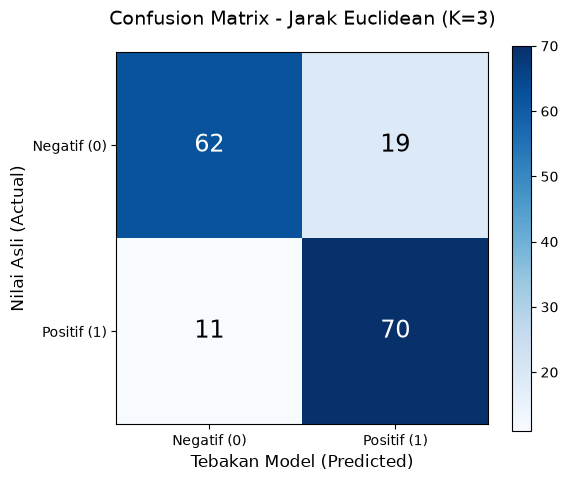

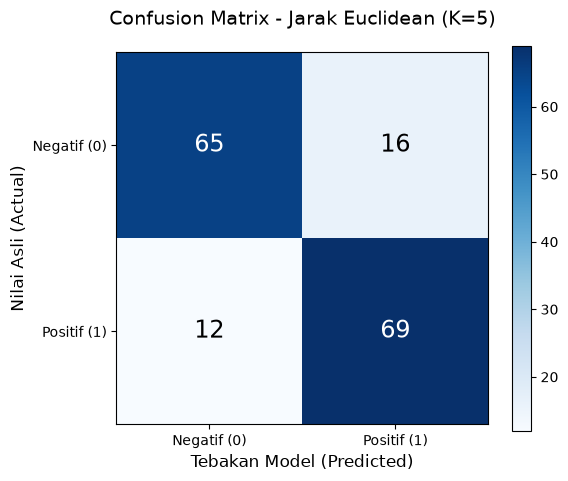

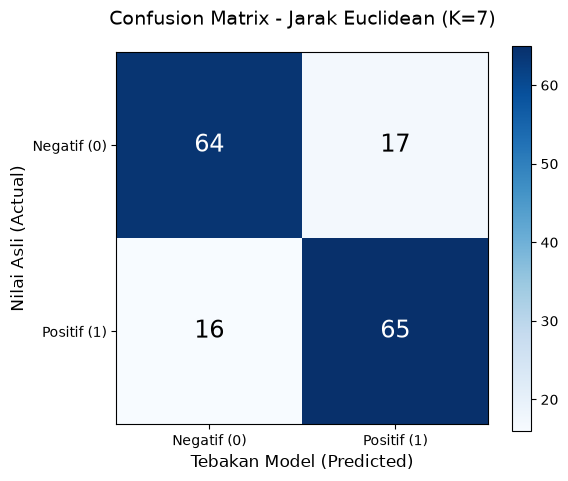

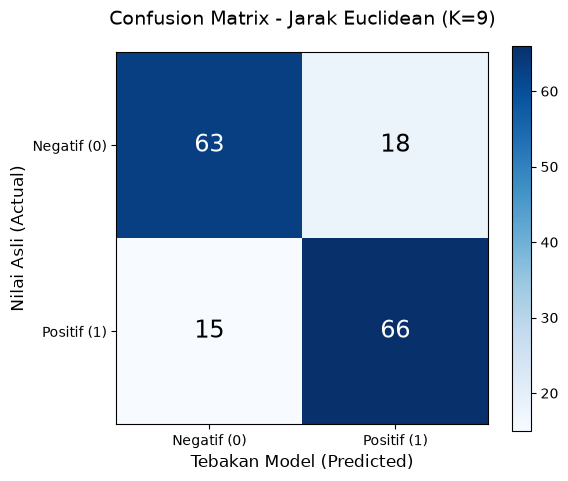

In [31]:
datasetEighty = DatasetEvaluator(readyDf, training_size=0.8)
datasetEighty.split_datasets()
datasetEighty.evaluate_knn()

# 75:25

Dimensi data latih - (604, 5),(604,)
Dimensi data validasi - (202, 5),(202,)
Results for Euclidean Distance (K=3)
Accuracy: 81.19%, Precision: 79.44%, Recall: 84.16%, F1-Score: 81.73%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=5)
Accuracy: 79.70%, Precision: 79.41%, Recall: 80.20%, F1-Score: 79.80%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=7)
Accuracy: 77.72%, Precision: 78.57%, Recall: 76.24%, F1-Score: 77.39%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=9)
Accuracy: 80.20%, Precision: 80.81%, Recall: 79.21%, F1-Score: 80.00%
--------------------------------------------------------------------------------


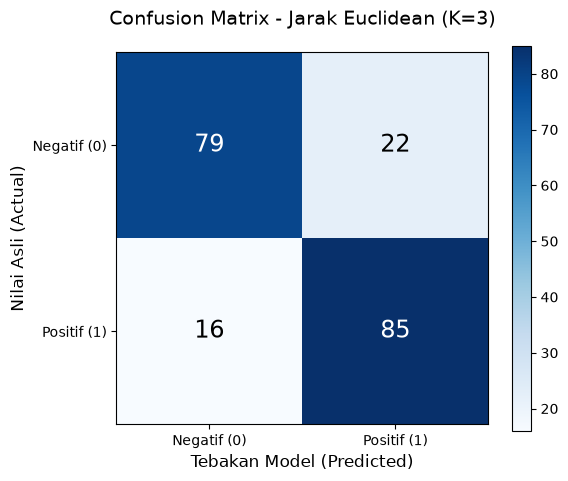

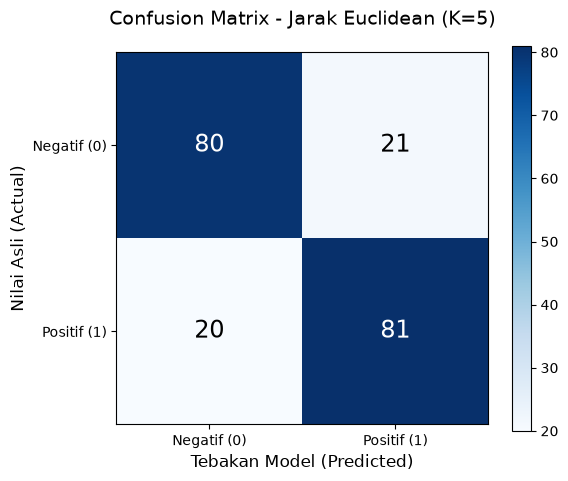

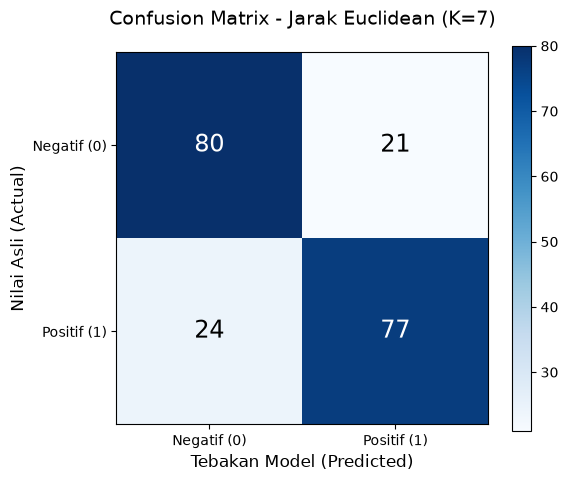

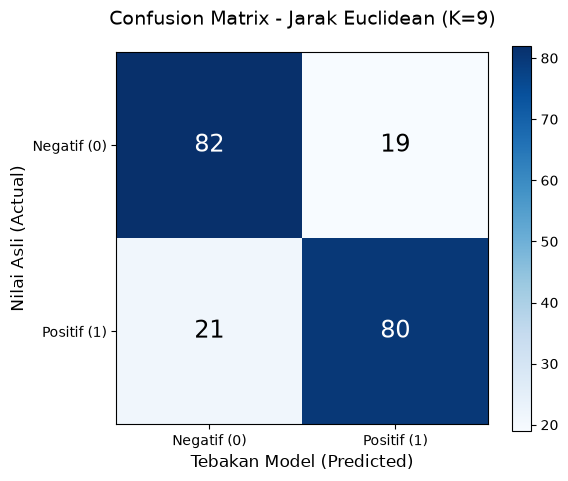

In [30]:
datasetSeventyFive = DatasetEvaluator(readyDf, training_size=0.75)
datasetSeventyFive.split_datasets()
datasetSeventyFive.evaluate_knn()

# 90:10

Dimensi data latih - (725, 5),(725,)
Dimensi data validasi - (81, 5),(81,)
Results for Euclidean Distance (K=3)
Accuracy: 80.25%, Precision: 78.72%, Recall: 86.05%, F1-Score: 82.22%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=5)
Accuracy: 79.01%, Precision: 80.95%, Recall: 79.07%, F1-Score: 80.00%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=7)
Accuracy: 79.01%, Precision: 80.95%, Recall: 79.07%, F1-Score: 80.00%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=9)
Accuracy: 79.01%, Precision: 79.55%, Recall: 81.40%, F1-Score: 80.46%
--------------------------------------------------------------------------------


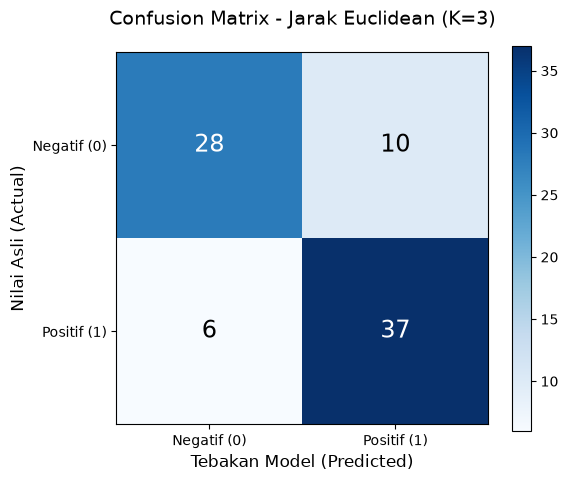

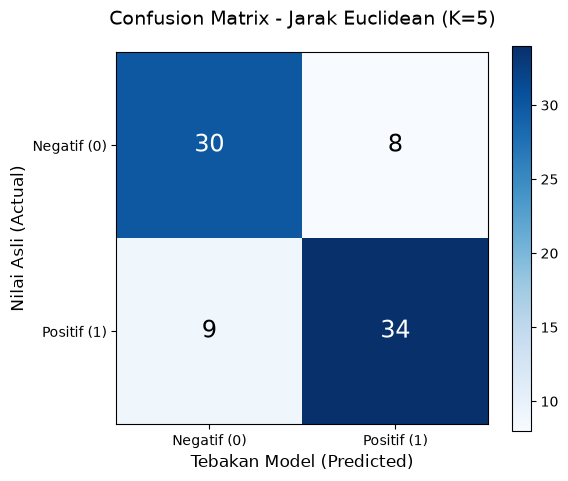

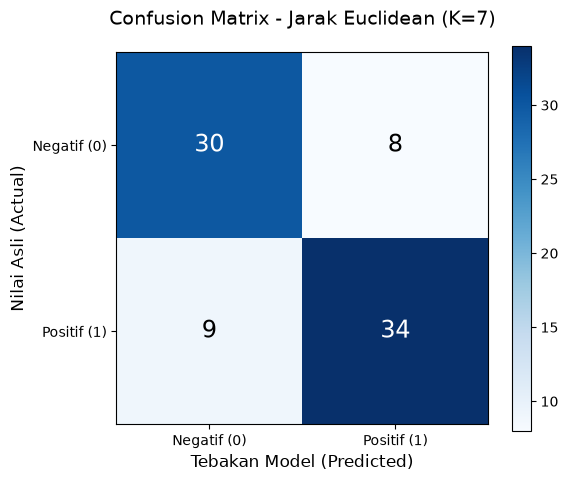

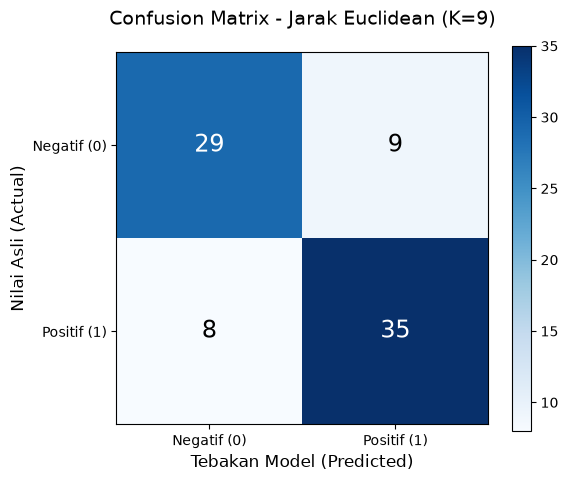

In [32]:
datasetNinety = DatasetEvaluator(readyDf, training_size=0.9)
datasetNinety.split_datasets()
datasetNinety.evaluate_knn()

# K-Fold Cross Validation => K = 4, 5, 10

In [3]:
K = np.array([4, 5, 10])

In [4]:
kFoldDf = pd.read_csv("dataset_preprocessed.csv")
kFoldDf

,umur,sistolik,diastolik,gds,transformed_gender,norm_sistolik,norm_diastolik,norm_umur,norm_gds,diagnosa
0,66.0,130.000000,80.000000,156.0,1,0.454545,0.29000,0.100152,0.160187,1
1,61.0,122.000000,74.000000,341.0,1,0.381818,0.23000,0.092564,0.447900,1
2,61.0,128.000000,79.000000,186.0,1,0.436364,0.28000,0.092564,0.206843,1
3,38.0,124.000000,80.000000,86.0,1,0.400000,0.29000,0.057663,0.051322,0
4,36.0,130.000000,80.000000,249.0,1,0.454545,0.29000,0.054628,0.304821,1
...,...,...,...,...,...,...,...,...,...,...
801,29.0,121.000000,82.000000,94.0,1,0.372727,0.31000,0.044006,0.063764,0
802,73.0,150.000000,90.000000,141.0,1,0.636364,0.39000,0.110774,0.136858,1
803,61.0,126.200767,80.202046,154.0,1,0.420007,0.29202,0.092564,0.157076,1
804,39.0,131.000000,84.000000,407.0,1,0.463636,0.33000,0.059181,0.550544,0


In [5]:
# Siapkan list untuk nyimpen semua metrik
results_storage = []

for k_count in K:
    for fold_index in range(k_count):
        kFold = KFoldCrossValidation(kFoldDf, k_count)
        [train_data, test_data] = kFold.get_train_test_split(fold_index)
        k_X_train = train_data[['transformed_gender', 'norm_sistolik', 'norm_diastolik', 'norm_umur', 'norm_gds']]
        k_y_train = train_data['diagnosa']
        k_X_test = test_data[['transformed_gender', 'norm_sistolik', 'norm_diastolik', 'norm_umur', 'norm_gds']]
        k_y_test = test_data['diagnosa']
        
        for k_knn in np.array([3, 5, 7, 9]):
            print(f"Fold {fold_index + 1}/{k_count} - K={k_knn}")
            knn = KNN(k=k_knn)
            knn.fit(k_X_train, k_y_train)

            predictions = knn.predict(k_X_test.values)
            y_pred = predictions['Euclidean']
            
            # for distance_type, y_pred in predictions.items():
            evaluator = MetricsEvaluator(y_pred, k_y_test.values)
            
            results_storage.append({
                'K_Fold': k_count,
                'Fold': fold_index + 1,
                'K_KNN': k_knn,
                'Distance': 'Euclidean',
                'Accuracy': evaluator.accuracy(),
                'Precision': evaluator.precision(),
                'Recall': evaluator.recall(),
                'F1_Score': evaluator.f1_score()
            })

Fold 1/4 - K=3
Fold 1/4 - K=5
Fold 1/4 - K=7
Fold 1/4 - K=9
Fold 2/4 - K=3
Fold 2/4 - K=5
Fold 2/4 - K=7
Fold 2/4 - K=9
Fold 3/4 - K=3
Fold 3/4 - K=5
Fold 3/4 - K=7
Fold 3/4 - K=9
Fold 4/4 - K=3
Fold 4/4 - K=5
Fold 4/4 - K=7
Fold 4/4 - K=9
Fold 1/5 - K=3
Fold 1/5 - K=5
Fold 1/5 - K=7
Fold 1/5 - K=9
Fold 2/5 - K=3
Fold 2/5 - K=5
Fold 2/5 - K=7
Fold 2/5 - K=9
Fold 3/5 - K=3
Fold 3/5 - K=5
Fold 3/5 - K=7
Fold 3/5 - K=9
Fold 4/5 - K=3
Fold 4/5 - K=5
Fold 4/5 - K=7
Fold 4/5 - K=9
Fold 5/5 - K=3
Fold 5/5 - K=5
Fold 5/5 - K=7
Fold 5/5 - K=9
Fold 1/10 - K=3
Fold 1/10 - K=5
Fold 1/10 - K=7
Fold 1/10 - K=9
Fold 2/10 - K=3
Fold 2/10 - K=5
Fold 2/10 - K=7
Fold 2/10 - K=9
Fold 3/10 - K=3
Fold 3/10 - K=5
Fold 3/10 - K=7
Fold 3/10 - K=9
Fold 4/10 - K=3
Fold 4/10 - K=5
Fold 4/10 - K=7
Fold 4/10 - K=9
Fold 5/10 - K=3
Fold 5/10 - K=5
Fold 5/10 - K=7
Fold 5/10 - K=9
Fold 6/10 - K=3
Fold 6/10 - K=5
Fold 6/10 - K=7
Fold 6/10 - K=9
Fold 7/10 - K=3
Fold 7/10 - K=5
Fold 7/10 - K=7
Fold 7/10 - K=9
Fold 8/10 - 

In [25]:
# Tanpa grouping, langsung convert list of dicts ke Pandas DataFrame
pd.set_option('display.max_rows', None)
df_results = pd.DataFrame(results_storage)
sorted_df_results = df_results.sort_values(by='Accuracy', ascending=False, ignore_index=True)
sorted_df_results

,K_Fold,Fold,K_KNN,Distance,Accuracy,Precision,Recall,F1_Score
0,10,5,3,Euclidean,0.901235,0.909091,0.909091,0.909091
1,5,4,5,Euclidean,0.888199,0.942029,0.822785,0.878378
2,5,1,3,Euclidean,0.870370,0.847059,0.900000,0.872727
3,10,7,5,Euclidean,0.862500,0.882353,0.810811,0.845070
4,4,1,3,Euclidean,0.861386,0.851485,0.868687,0.860000
5,10,1,3,Euclidean,0.851852,0.809524,0.894737,0.850000
6,10,5,5,Euclidean,0.851852,0.900000,0.818182,0.857143
7,10,3,3,Euclidean,0.851852,0.833333,0.833333,0.833333
8,10,7,3,Euclidean,0.850000,0.878788,0.783784,0.828571
9,10,7,7,Euclidean,0.850000,0.878788,0.783784,0.828571


In [ ]:
# Grouping berdasarkan K_Fold dan K_KNN, lalu hitung rata-rata dari semua fold untuk setiap kombinasi K_Fold dan K_KNN
df_avg_double_k = df_results.groupby(['K_Fold', 'K_KNN'])[['Accuracy', 'Precision', 'Recall', 'F1_Score']].mean().reset_index()
df_avg_double_k

,K_Fold,K_KNN,Accuracy,Precision,Recall,F1_Score
0,4,3,0.834953,0.832871,0.829066,0.830385
1,4,5,0.823814,0.823566,0.814274,0.818673
2,4,7,0.808920,0.804572,0.804321,0.804075
3,4,9,0.813919,0.806974,0.814455,0.810455
4,5,3,0.832459,0.825796,0.833751,0.828292
5,5,5,0.822598,0.819343,0.821285,0.819112
6,5,7,0.811410,0.807000,0.811744,0.807422
7,5,9,0.808949,0.809274,0.801345,0.804092
8,10,3,0.829985,0.823167,0.830767,0.824886
9,10,5,0.817685,0.810389,0.819282,0.813508


In [27]:
pd.reset_option('display.max_rows')